# Brain Tumor MRI Classification - Model Training

In [1]:
# Imports

from pathlib import Path
import random
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

warnings.filterwarnings("ignore")

print("TensorFlow :", tf.__version__)

TensorFlow : 2.21.0


In [2]:
# Configuration

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

MODELS_DIR = PROJECT_ROOT / "models"

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Load Training Dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [4]:
# Class Names

CLASS_NAMES = train_dataset.class_names

NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)

# Optimize Dataset

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(AUTOTUNE)
)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# Data Augmentation

data_augmentation = keras.Sequential(

[
    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

],

name="augmentation"

)

data_augmentation

<Sequential name=augmentation, built=False>

In [6]:
# Load EfficientNetB0

base_model = EfficientNetB0(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

)

base_model.trainable = False

print("Base Model Loaded")

Base Model Loaded


In [7]:
# Build Model

inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(

NUM_CLASSES,

activation="softmax"

)(x)

model = Model(

inputs,

outputs,

name="BrainTumorClassifier"

)

In [8]:
# Compile Model

model.compile(

optimizer=keras.optimizers.Adam(

learning_rate=1e-4

),

loss="categorical_crossentropy",

metrics=[

"accuracy"

]

)

In [9]:
# Model Summary

model.summary()

Model: "BrainTumorClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,679 (16.73 MB)

 Trainable params: 332,036 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [10]:
# Callbacks

checkpoint_path = MODELS_DIR / "best_model.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

In [11]:
# Train Model

EPOCHS = 15

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.6156 - loss: 1.0790
Epoch 1: val_accuracy improved from None to 0.71964, saving model to c:\Users\SAINATH\github projects\brain-tumor-detector\models\best_model.keras

Epoch 1: finished saving model to c:\Users\SAINATH\github projects\brain-tumor-detector\models\best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 528ms/step - accuracy: 0.6156 - loss: 1.0790 - val_accuracy: 0.7196 - val_loss: 0.7283 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7527 - loss: 0.7045
Epoch 2: val_accuracy improved from 0.71964 to 0.77232, saving model to c:\Users\SAINATH\github projects\brain-tumor-detector\models\best_model.keras

Epoch 2: finished saving model to c:\Users\SAINATH\github projects\brain-tumor-detector\models\best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 511ms/step - accuracy: 0.7527 - loss: 0.7045 - val_accuracy: 0.7723 - val_loss: 0.5779 - learning_rate: 1.0000e-04
Epoch

In [12]:
# Save Training History

history_path = MODELS_DIR / "training_history.pkl"

with open(history_path, "wb") as file:
    pickle.dump(history.history, file)

print("Training history saved successfully.")

Training history saved successfully.


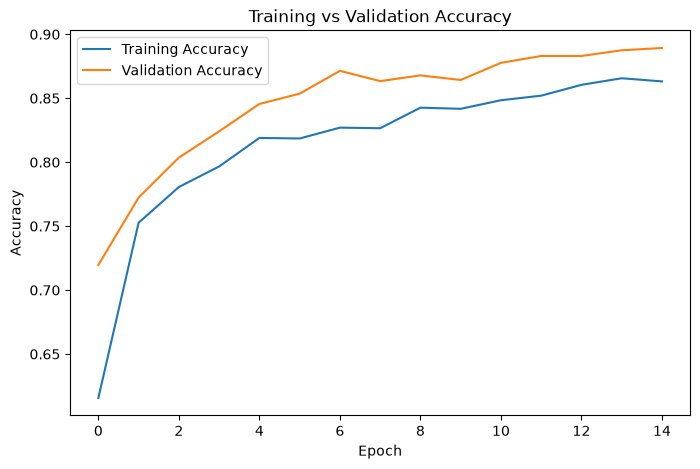

In [13]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

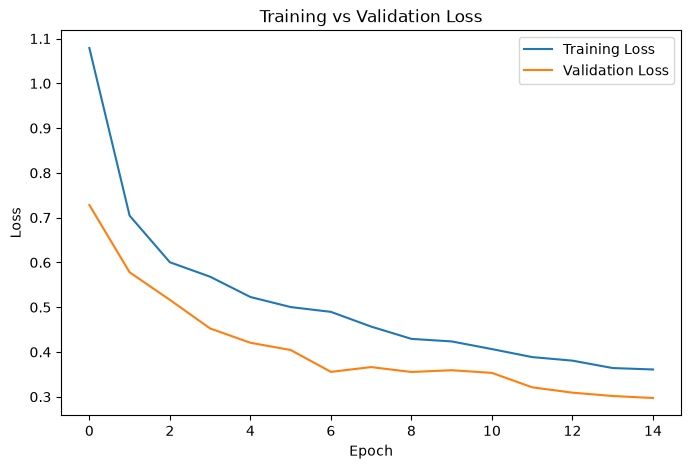

In [14]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
# Save Class Names

class_path = MODELS_DIR / "class_names.pkl"

with open(class_path, "wb") as file:
    pickle.dump(CLASS_NAMES, file)

print("Class names saved successfully.")

Class names saved successfully.


In [16]:
# Verify Saved Files

print("Saved Files:\n")

for file in MODELS_DIR.iterdir():
    print(file.name)

Saved Files:

best_model.keras
class_names.pkl
pipeline_info.pkl
training_history.pkl


In [17]:
# Final Training Summary

print("=" * 60)

print("Model Training Completed Successfully")

print("=" * 60)

print("Model Name        :", model.name)
print("Architecture      : EfficientNetB0")
print("Image Size        :", IMAGE_SIZE)
print("Batch Size        :", BATCH_SIZE)
print("Epochs            :", EPOCHS)
print("Classes           :", NUM_CLASSES)

print("=" * 60)

print("Artifacts Saved")

print("- best_model.keras")
print("- class_names.pkl")
print("- training_history.pkl")

print("=" * 60)

Model Training Completed Successfully
Model Name        : BrainTumorClassifier
Architecture      : EfficientNetB0
Image Size        : (224, 224)
Batch Size        : 32
Epochs            : 15
Classes           : 4
Artifacts Saved
- best_model.keras
- class_names.pkl
- training_history.pkl


In [18]:
# Count Images in Training Folder

import os

total_images = 0

for class_name in os.listdir(TRAIN_DIR):
    class_path = TRAIN_DIR / class_name

    if class_path.is_dir():
        count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        total_images += count

        print(f"{class_name:<15} : {count}")

print("-" * 30)
print(f"Total Images : {total_images}")

glioma          : 1400
meningioma      : 1400
notumor         : 1400
pituitary       : 1400
------------------------------
Total Images : 5600
